Exercises XP - Exercise 1
Understanding Data Visualization
importance of Data Visualization in simplifying complex datasets, giving the dataset better visual format wchich is easy to understand, the second one is understanding trends and patterns, which raises the quality of decision-making.The visualization is also able to reveal the relationships between variables, whilst detecting the outliners and anomalies.


The line graph, generally speaking, shows trends over time or any given period and displays continious data. It is possible to outline multiple variables over a period, as long as data is continious

In [ ]:
import matplotlib.pyplot as plt
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
temperatures = [72, 74, 76, 80, 82, 78, 75]



The tempreture variation in temperatures = [72, 74, 76, 80, 82, 78, 75]
in any given standard week from the list days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

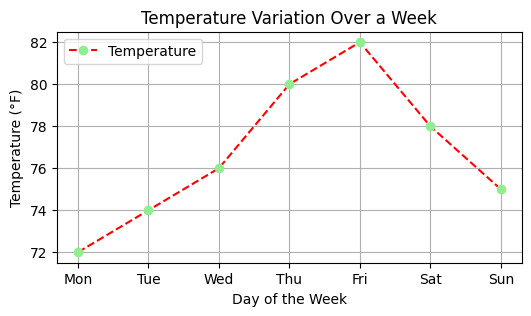

In [ ]:

plt.figure(figsize=(6, 3))
plt.plot(days, temperatures, marker='o', linestyle='--', color='red', label='Temperature', markerfacecolor='lightgreen', markeredgecolor='lightgreen')
plt.title('Temperature Variation Over a Week')
plt.xlabel('Day of the Week',fontsize=10)
plt.ylabel('Temperature (°F)')
plt.grid(True)
plt.legend()
plt.show()

 Exercise 3 : Visualizing Monthly Sales with a Bar Chart

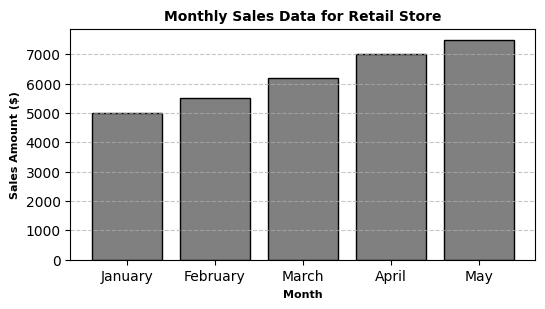

In [ ]:
months = ["January", "February", "March", "April", "May"]
sales = [5000, 5500, 6200, 7000, 7500]
plt.figure(figsize=(6, 3))
plt.bar(months, sales, color='grey', edgecolor='black')
plt.xlabel("Month", fontsize=8, fontweight='bold')
plt.ylabel("Sales Amount ($)", fontsize=8, fontweight='bold')
plt.title("Monthly Sales Data for Retail Store", fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

Exercise 4

In [4]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
sales= pd.read_csv('sales_data.csv')
sales.head()

Saving sales_data.csv to sales_data.csv


,date,product,category,price,quantity,revenue
0,2022-01-01,Smartphone,Electronics,600.0,10.0,6000.0
1,2022-01-01,Laptop,Electronics,1200.0,5.0,6000.0
2,2022-01-02,T-Shirt,Clothing,20.0,50.0,1000.0
3,2022-01-03,Headphones,Electronics,100.0,20.0,2000.0
4,2022-01-04,T-Shirt,Clothing,20.0,25.0,500.0


In [ ]:
sales.info()
sales[['product']].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      369 non-null    object 
 1   product   369 non-null    object 
 2   category  369 non-null    object 
 3   price     367 non-null    float64
 4   quantity  368 non-null    float64
 5   revenue   368 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.4+ KB


,product
count,369
unique,14
top,Smartphone
freq,82


checking the missing data, and identifyimg the rows which containg the missing data

In [30]:
missing_data_summary = sales.isnull().sum()
print(missing_data_summary)
rows_with_missing_data = sales[sales.isnull().any(axis=1)]
print(rows_with_missing_data)

date        0
product     0
category    0
price       2
quantity    1
revenue     1
dtype: int64
           date     product     category  price  quantity  revenue
96   2022-04-05  Smartwatch  Accessories  200.0      10.0      NaN
122  2022-05-01  Smartphone  Electronics  600.0       NaN   6600.0
193  2022-07-11       Watch  Accessories    NaN      15.0   2250.0
320  2022-11-13      Wallet  Accessories    NaN      35.0   1050.0


revenue can be easily calculated = price X quantity;
missing quantity = revenue / price;
price = revenue / quantity

In [8]:
sales['revenue'] = sales.apply(
    lambda row: row['price'] * row['quantity'] if pd.isnull(row['revenue']) else row['revenue'],
    axis=1
)
sales['quantity'] = sales.apply(
    lambda row: row['revenue'] / row['price'] if pd.isnull(row['quantity']) else row['quantity'],
    axis=1
)
sales['price'] = sales.apply(
    lambda row: row['revenue'] / row['quantity'] if pd.isnull(row['price']) else row['price'],
    axis=1
)
sales.info()
missing_data_summary = sales.isnull().sum()
print(missing_data_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      369 non-null    object 
 1   product   369 non-null    object 
 2   category  369 non-null    object 
 3   price     369 non-null    float64
 4   quantity  369 non-null    float64
 5   revenue   369 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.4+ KB
date        0
product     0
category    0
price       0
quantity    0
revenue     0
dtype: int64


Total quantity of products sold calculated as sum in column['quantity']

In [51]:
total_quantity = sales['quantity'].sum()
print(f"The total quantity of products sold by the company is {total_quantity:.2f}.")

The total quantity of products sold by the company is 5371.00.


the category that had the highest revenue and calculate how much revenue it generated would be defined as max for each goup of product

In [10]:
category_revenue = sales.groupby('category')['revenue'].sum()


highest_revenue_category = category_revenue.idxmax()
highest_revenue_value = category_revenue.max()
print(f"The category with the highest revenue is '{highest_revenue_category}' with a total revenue of {highest_revenue_value:.2f}.")


The category with the highest revenue is 'Electronics' with a total revenue of 516080.00.


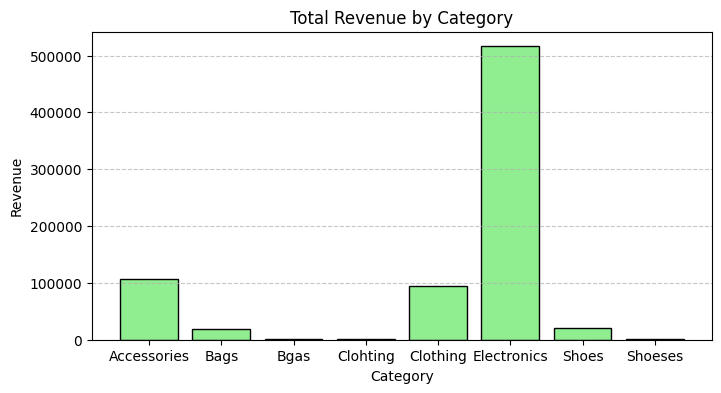

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(category_revenue.index, category_revenue.values, color='lightgreen', edgecolor='black')
plt.title('Total Revenue by Category', fontsize=12)
plt.xlabel('Category', fontsize=10)
plt.ylabel('Revenue', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



In [54]:
median_revenue_per_sale = sales['revenue'].median()
print(f"The median revenue per sale is {median_revenue_per_sale:.2f}.")
average_revenue_per_sale = sales['revenue'].mean()
print(f"The average revenue per sale is {average_revenue_per_sale:.2f}.")


The median revenue per sale is 1200.00.
The average revenue per sale is 2060.51.


In order to do the Quarterly Revenue , it is necessary to bring date format to a date one and introduce new future 'Qn', then we need to group revenue by quarters and sum the revenue accordingly

In [62]:
sales['date'] = pd.to_datetime(sales['date'])
sales['quarter'] = sales['date'].dt.to_period('Q')
quarter_revenue = sales.groupby('quarter')['revenue'].sum()
print(quarter_revenue)




quarter
2022Q1    182100.0
2022Q2    185970.0
2022Q3    197680.0
2022Q4    194580.0
Freq: Q-DEC, Name: revenue, dtype: float64


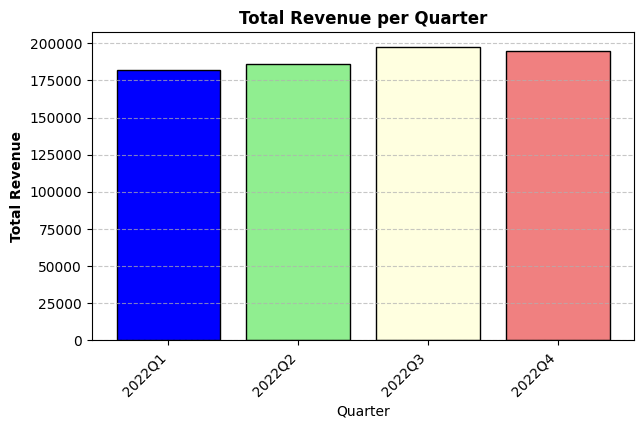

In [68]:
plt.figure(figsize=(7, 4))
bars = plt.bar(quarter_revenue.index.astype(str), quarter_revenue.values, color=['blue', 'lightgreen', 'lightyellow', 'lightcoral'], edgecolor='black')
plt.title('Total Revenue per Quarter', fontsize=12, fontweight='bold')
plt.xlabel('Quarter', fontsize=10)
plt.ylabel('Total Revenue', fontsize=10, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)


a simple line plot using Matplotlib. Plot the function y = x^2 for x values ranging from -10 to 10. Add a title and label the x and y axes.

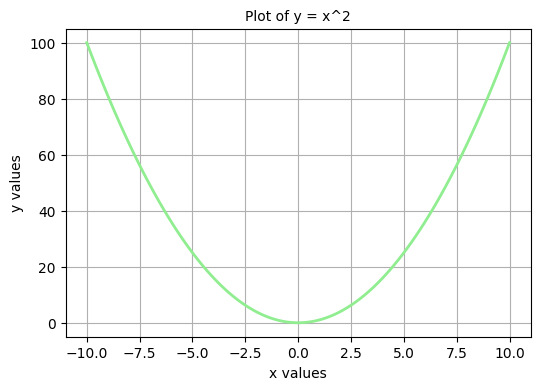

In [70]:
import numpy as np
x = np.linspace(-10, 10, 100)
y = x**2
plt.figure(figsize=(6, 4))
plt.plot(x, y, color='lightgreen', linewidth=2)
plt.title('Plot of y = x^2', fontsize=10)
plt.xlabel('x values', fontsize=10)
plt.ylabel('y values', fontsize=10)
plt.grid(True)
plt.show()

a bar chart to display the sales data of four different products (A, B, C, D) in a week. The sales values are 15, 30, 45, and 20 respectively. Label the chart appropriately.

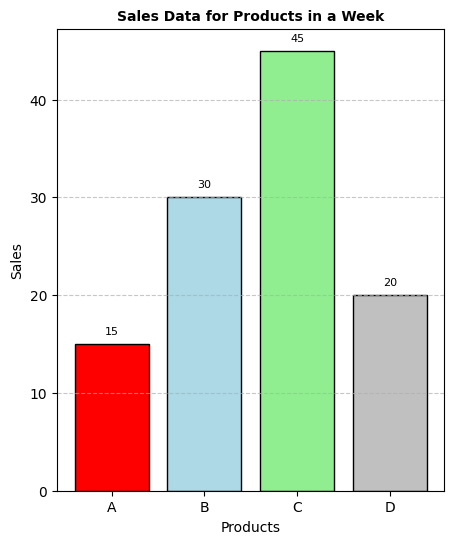

In [82]:
products = ['A', 'B', 'C', 'D']
sales = [15, 30, 45, 20]
plt.figure(figsize=(5, 6))
colors = ['red', 'lightblue', 'lightgreen', 'silver']
plt.bar(products, sales, color=colors, edgecolor='black')
plt.title('Sales Data for Products in a Week', fontsize=10, fontweight='bold')
plt.xlabel('Products', fontsize=10)
plt.ylabel('Sales', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, value in enumerate(sales):
    plt.text(i, value + 1, f'{value}', ha='center', fontsize=8)
plt.show()


a pie chart representing the following data about favorite fruits of a group of people: Apples (40%), Bananas (30%), Cherries (20%), and Dates (10%). Customize the chart with different colors for each fruit and add a legend.

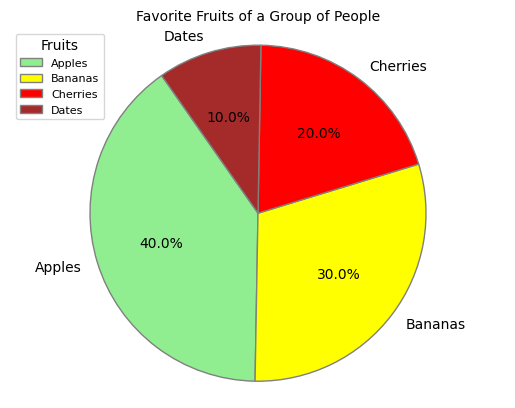

In [94]:
import matplotlib.pyplot as plt
fruits = ['Apples', 'Bananas', 'Cherries', 'Dates']
percentages = [40, 30, 20, 10]
colors = ['lightgreen','yellow','red','brown']
plt.pie(percentages, labels=fruits, colors=colors, autopct='%1.1f%%', startangle=125, wedgeprops={'edgecolor': 'grey'})
plt.title('Favorite Fruits of a Group of People', fontsize=10)
plt.legend(fruits, title='Fruits', loc='upper left', fontsize=8)
plt.axis('equal')
plt.show()
